In [1]:
import pandas as pd
import glob

file_path = glob.glob('/content/*.csv')[0]
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [2]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nColumn names:")
print(df.columns.tolist())

Missing values in each column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3    

In [3]:
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

df = df.drop_duplicates()

print("Missing values after cleaning:", df.isnull().sum().sum())
print("Dataset shape after cleaning:", df.shape)

Missing values after cleaning: 0
Dataset shape after cleaning: (4000, 28)


In [4]:
season_summary = df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean')
).round(2)

season_summary

,Average_Yield,Average_Production,Average_Profit,Average_Rainfall,Average_Water_Used
Season,,,,,
Kharif,5.63,46.31,178914.65,849.20,6102.20
Rabi,5.04,41.49,87689.47,437.62,5846.99
Zaid,4.64,38.89,-24804.82,304.65,6419.89


/tmp/ipykernel_750/1275888024.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', estimator='mean', errorbar=None, palette='Set2')


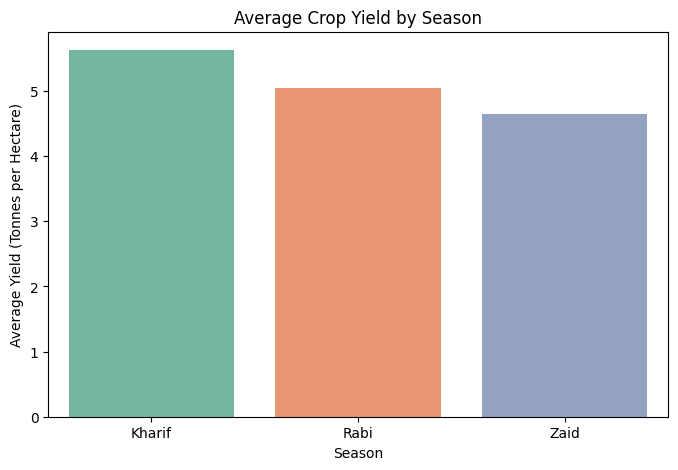

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', estimator='mean', errorbar=None, palette='Set2')
plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes per Hectare)')
plt.show()

/tmp/ipykernel_750/2903810681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Profit_INR', estimator='mean', errorbar=None, palette='Set1')


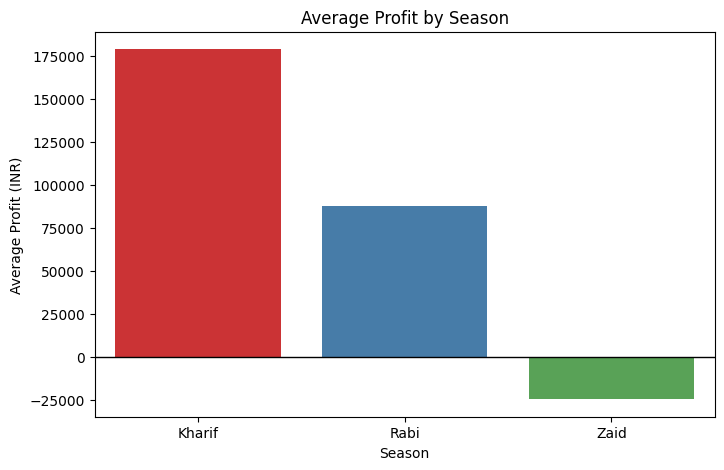

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Season', y='Profit_INR', estimator='mean', errorbar=None, palette='Set1')
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, color='black', linewidth=1)
plt.show()

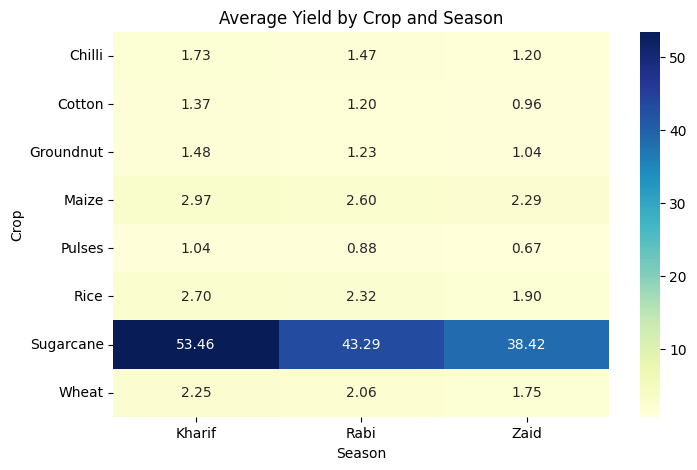

In [7]:
crop_season_yield = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(crop_season_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

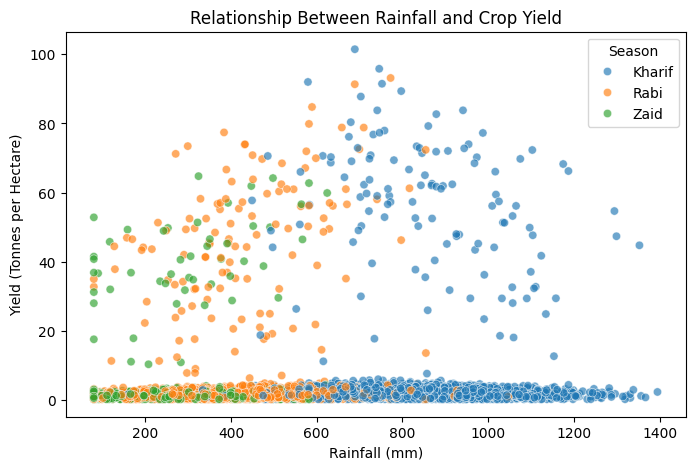

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.65
)
plt.title('Relationship Between Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.show()

In [9]:
selected_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Profit_INR'
]

correlation = df[selected_columns].corr().round(2)
correlation

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Water_Used_m3,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,1.00,0.20,0.52,0.51,0.02,0.00,0.03,0.11
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.02,0.02,0.01,0.01
Humidity_pct,0.52,0.14,1.00,0.45,0.02,-0.00,0.01,0.06
Soil_Moisture_pct,0.51,0.08,0.45,1.00,0.01,0.00,0.01,0.09
Fertilizer_kg_ha,0.02,0.02,0.02,0.01,1.00,0.00,0.00,-0.07
Water_Used_m3,0.00,0.02,-0.00,0.00,0.00,1.00,0.39,0.19
Yield_Tonnes_Ha,0.03,0.01,0.01,0.01,0.00,0.39,1.00,0.49
Profit_INR,0.11,0.01,0.06,0.09,-0.07,0.19,0.49,1.00


/tmp/ipykernel_750/1723023557.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


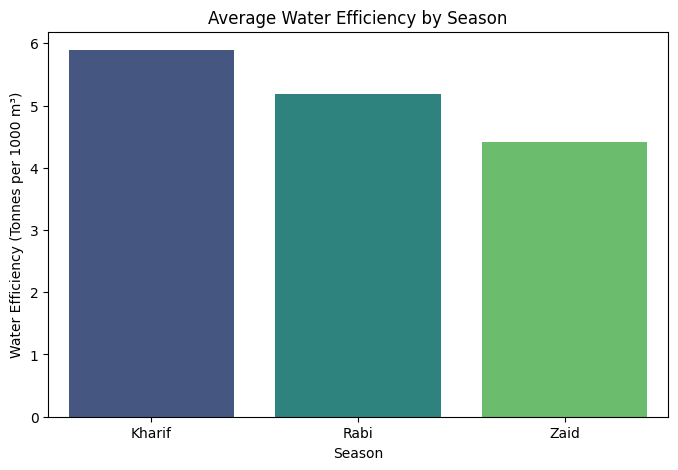

In [10]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean',
    errorbar=None,
    palette='viridis'
)
plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.show()

In [11]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).round(2)
crop_profit

,Profit_INR
Crop,
Sugarcane,817187.99
Chilli,750878.34
Cotton,124546.92
Groundnut,44858.12
Pulses,-4238.05
Maize,-83978.33
Rice,-102213.50
Wheat,-123398.34


/tmp/ipykernel_750/1235468601.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_profit.index, y=crop_profit.values, palette='coolwarm')


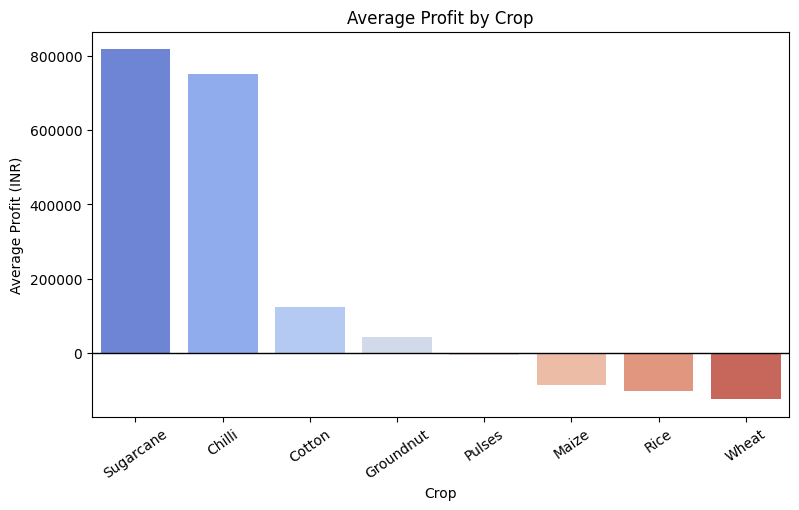

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(x=crop_profit.index, y=crop_profit.values, palette='coolwarm')
plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=35)
plt.show()

## Key Findings and Recommendations

- Kharif showed the highest average yield, production, profit and water efficiency among the three seasons.
- Rabi showed moderate agricultural performance, while Zaid had the lowest average yield and an average loss.
- Sugarcane had the highest average yield and profit across all seasons. Chilli was the second most profitable crop.
- Wheat, Rice, Maize and Pulses showed average losses, so their cost, pricing and cultivation practices need further review.
- Yield and profit had a moderate positive relationship. Water use also showed a moderate positive relationship with yield.
- Rainfall alone did not show a strong direct relationship with yield, indicating that crop type and other farm conditions also affect performance.

### Recommendations

- Prioritize suitable high-performing crops such as Sugarcane and Chilli where local conditions support them.
- Improve planning and cost control for loss-making crops, especially Wheat and Rice.
- Focus on water-efficient farming practices during Rabi and Zaid seasons.
- Use seasonal data along with crop-specific conditions instead of depending only on rainfall for planning.